In [566]:
# auto reload modules
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import copy as copy
import time as tpy
import pandas as pd
from scipy import stats,signal, fft
from scipy.stats import norm, wilcoxon, shapiro
import sys, os
import sys
import figurefirst as fifi
from IPython.display import display,SVG
from globalVars import *
from load_data import *
from analysis import mean_and_interquartile,WilcoxonTest
from collect_data import findFilename, getrawdata, get_data, analyze
import plotting_variables
from plotting_variables import TINY_SIZE, SMALL_SIZE, MEDIUM_SIZE, BIGGER_SIZE, MARKER_SIZE, python_colors, colors, yfill, ufill, gfill, rfill, bfill
from matplotlib.colors import to_rgba
from matplotlib.transforms import blended_transform_factory

print('data length = ',N)
print('primes = ',primes)
print('base freq = ',base_freq)
print('IX = ',IX)
print('freqs = ',freqs)
print('omegas = ',omegas)
print('T = ',T) # total time 40 seconds
print('t = ',t) # timestamps
print('fs = ',fs)
print('sample_period (dt)= ',dt)
print('xf = ',xf) # frequency domain x-axis, shape (N//2,)
print('s = ',s)
print('z = ',z)
print('soM = ',soM)
print('zero = ',zero)
print('first = ',first)
print('second = ',second)

print('subject_num = ',subject_num)
print('condition_num (orders) = ',condition_num)
print('trial_num = ',trial_num)
print('trial_num of baseline = ',trial_num_base)
print('\n')

# interface transfer function parameters (subjects x trials x number of parameters)
print('0th-order interface parameters, G_parameters shape= ',G_parameters[0].shape)
print('1st-order interface parameters, G_parameters shape= ',G_parameters[1].shape)
print('2nd-order interface parameters, G_parameters shape= ',G_parameters[2].shape)
# print(G_parameters[0].shape,G_parameters[1].shape,G_parameters[2].shape) 
print('\n')

# freqeuncy domain signals
print('Interface transfer function, Gs shape=', Gs.shape) # interface transfer function (subjects x condition x trials x stim frequencies)
print('Human transfer function, Hs shape=',Hs.shape) # human transfer function (subjects x condition x trials x stim frequencies)
print('Disturbance signals, Ds shape=', Ds.shape) # disturbances (subjects x condition x trials x number of frequencies)
print('Human inputs signals, UHs shape=', UHs.shape) # human inputs (subjects x condition x trials x number of frequencies)
print('Interface inputs signals, UIs shape=', UGs.shape) # interface inputs (subjects x condition x trials x number of frequencies)
print('Output signals, Ys shape=', Ys.shape) # output (subjects x condition x trials x number of frequencies)
print('\n')
print('Baseline interface transfer function, Gs_base shape=', Gs_base.shape) # interface transfer function (subjects x trials x stim frequencies)
print('\n')

# time domain signals
print('time-domain disturbances, ds shape=', ds.shape) # disturbances (subjects x condition x trials x number of time points)
print('time-domain human inputs, uhs shape=', uhs.shape) # human inputs (subjects x condition x trials x number of time points)
print('time-domain interface inputs, ugs shape=', ugs.shape) # interface inputs (subjects x condition x trials x number of time points)
print('time-domain outputs, ys shape=', ys.shape) # output (subjects x condition x trials x number of time points)
print('time-domain MSE per trial, errors shape=',errors.shape) # errors (subjects x condition x trials) #np.sum(abs(outs)**2)
print('\n')

# continuous M IS -2(s-2.2)/(s^2+3.6s+4)
M = -2*(s(omegas)-2.2)/(s(omegas)**2+3.6*s(omegas)+4)

soM_ = lambda s : 1/(s**2 + s)      #2nd order machine in multimodal exp 
M_other = soM_(s(omegas))           #M_hat = 1/ ((jw)^2 + (jw)) at stimulated frequencies
# check M and soM
# plt.figure(figsize=(3,2))
# plt.plot(np.abs(soM),'-o',label='soM (discrete)')
# plt.plot(np.abs(M),'-o',label='M (continous)')
# # plt.plot(np.abs(M_other),'-o',label='M other exp (continous)')
# plt.xlabel('stim freqs')
# plt.legend()
# plt.show()

# initial interfaces (I stars) for each condition
I_star_0 = Gs[0,0,0]
I_star_1 = Gs[0,1,0]
I_star_2 = Gs[0,2,0]
I_stars = [I_star_0,I_star_1,I_star_2]

# Loop Transfer functions (empirical data) 3 conditions
HMIs = Hs[:,:,:,IX]*soM*Gs # element-wise multiplication, shape = (subjects x condition x trials x frequencies)
print(HMIs.shape)
HMs = Hs[:,:,:,IX]*soM # element-wise multiplication, shape = (subjects x condition x trials x frequencies)
print(HMs.shape)
HIs = Hs[:,:,:,IX]*Gs # element-wise multiplication, shape = (subjects x condition x trials x frequencies)
print(HIs.shape)

# Loop Transfer functions (empirical data) baseline (passthrough interface)
HMIs_base = Hs_base[:,:,IX]*soM # element-wise multiplication, shape = (subjects x trials x frequencies), Gs = 1 passthrough
print(HMIs_base.shape)
HMs_base = Hs_base[:,:,IX]*soM # element-wise multiplication, shape = (subjects x trials x frequencies), Gs = 1 passthrough
print(HMs_base.shape)
HIs_base = Hs_base[:,:,IX] # element-wise multiplication, shape = (subjects x trials x frequencies), Gs = 1 passthrough 
print(HIs_base.shape)

lowest_x_freq = 8 # lowest ? stimulated frequency for the analysis

# frequency domain output at stimulated frequencies
Y_norm = np.linalg.norm(Ys[:,:,:,IX[:lowest_x_freq]],axis = 3) # across timesteps, one number per trial
Y_base_norm = np.linalg.norm(Ys_base[:,:,IX[:lowest_x_freq]],axis = 2) # across timesteps, one number per trial
print(Y_norm.shape),print(Y_base_norm.shape)

# human input for each trial ||u_H||2
UH_norm = np.linalg.norm(UHs[:,:,:,IX[:lowest_x_freq]],axis = 3)
UH_base_norm = np.linalg.norm(UHs_base[:,:,IX[:lowest_x_freq]],axis = 2)
# print(uH_norm.shape),print(uH_base_norm.shape)

# interface input for each trial ||u_I||2
UI_norm = np.linalg.norm(UGs[:,:,:,:lowest_x_freq],axis = 3) # already at the stimulated freq
UI_base_norm = np.linalg.norm(UGs_base[:,:,:lowest_x_freq],axis = 2)

# freq-domain interface loss 
lamH = 1.5 #Hyperparameter for tradeoff between interface effort and human effort
lamG = 0.5
D_norm = np.linalg.norm(np.asarray(Ds[:,:,:,IX[:lowest_x_freq]]),axis = 3)
D_norm_base = np.linalg.norm(np.asarray(Ds_base[:,:,IX[:lowest_x_freq]]),axis = 2)
interface_loss_freqdomain = (Y_norm + lamH*UH_norm + lamG*UI_norm) / D_norm
print(interface_loss_freqdomain.shape)
interface_loss_freqdomain_base = (Y_base_norm + lamH*UH_base_norm + lamG*UI_base_norm) / D_norm_base
print(interface_loss_freqdomain_base.shape)

# freq-domain human loss
HlamH = 1.5
human_loss_freqdomain = (Y_norm + HlamH*UH_norm) / D_norm
human_loss_freqdomain_base = (Y_base_norm + HlamH*UH_base_norm) / D_norm_base


def compute_smallest_distance(L_vals):
        # Smallest distance to -1
    distances = np.abs(L_vals + 1)  # distance from each L(iw) to -1
    idx_min = np.argmin(distances)
    min_point = L_vals[idx_min]
    min_dist = float(distances[idx_min])
    w_min = float(freqs[idx_min])
    return min_dist, w_min


L_min_distance = np.zeros((subject_num, condition_num,trial_num))
for sub in range(subject_num):
    for cond in range(condition_num):
        for trial in range(trial_num):
            L_example = Hs[sub, cond, trial, IX]*soM*Gs[sub, cond, trial]  #HMI open loop transfer function
            min_dist, w_min = compute_smallest_distance(L_example)
            # print(f'Minimum distance between L(iω) and -1 is {min_dist:.3f} at frequency {w_min:.3f}.')
            L_min_distance[sub, cond, trial] = min_dist

L_min_distance_base = np.zeros((subject_num, trial_num_base))
for sub in range(subject_num):
    for trial in range(trial_num_base):
            L_example = Hs_base[sub, trial, IX]*soM*Gs_base[sub, trial]
            min_dist, w_min = compute_smallest_distance(L_example)
            # print(f'Minimum distance between L(iω) and -1 is {min_dist:.3f} at frequency {w_min:.3f}.')
            L_min_distance_base[sub, trial] = min_dist

print(L_min_distance.shape)
print(L_min_distance_base.shape)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
data length =  2400
primes =  [ 2  3  5  7 11 13 17 19]
base freq =  0.05
IX =  [ 4  6 10 14 22 26 34 38]
freqs =  [0.1  0.15 0.25 0.35 0.55 0.65 0.85 0.95]
omegas =  [0.62831853 0.9424778  1.57079633 2.19911486 3.45575192 4.08407045
 5.34070751 5.96902604]
T =  40
t =  [0.00000000e+00 1.66736140e-02 3.33472280e-02 ... 3.99666528e+01
 3.99833264e+01 4.00000000e+01]
fs =  60
sample_period (dt)=  0.016666666666666666
xf =  [0.0000e+00 2.5000e-02 5.0000e-02 ... 2.9925e+01 2.9950e+01 2.9975e+01]
s =  <function <lambda> at 0x14dfaa020>
z =  <function <lambda> at 0x14e4745e0>
soM =  [ 0.71461011-0.8032687j   0.33652234-0.98372476j -0.33237591-0.86073923j
 -0.6163471 -0.48027949j -0.55477368+0.01684599j -0.46273241+0.11912274j
 -0.31404983+0.19698778j -0.26054454+0.2069847j ]
zero =  <function zero at 0x14e474720>
first =  <function first at 0x14e6a28e0>
second =  <function second at 0x14e6a3380>
subject_n

In [567]:
np.mean(UH_norm), np.mean(UI_norm)

(0.08992257126192249, 0.15637089143042632)

In [568]:
np.mean(UH_norm)*lamH, np.mean(UI_norm)*lamG*2

(0.13488385689288374, 0.15637089143042632)

In [569]:
np.mean(Y_norm)

0.22057401171364252

# Stats

In [570]:
import numpy as np
import pandas as pd
import statsmodels.stats.multitest as smm
from statsmodels.stats.anova import AnovaRM
from scipy import stats
from scipy.stats import wilcoxon, shapiro, friedmanchisquare

def pairwise_paired_ttests_bonferroni(comparisons, *, alpha=0.05, method='bonferroni', label=''):
    """Paired t-tests for each (name, d1, d2); print raw and multiplicity-adjusted p-values.

    comparisons : sequence of (name, d1, d2) with paired 1d arrays d1, d2.
    Returns list of dicts: name, p_raw, p_corr, reject.
    """
    p_raw_list = []
    for name, d1, d2 in comparisons:
        # test data normality
        _, p_sw1 = shapiro(d1)
        _, p_sw2 = shapiro(d2)
        if (p_sw1 > 0.05) and (p_sw2 > 0.05): # data is normal
            _stat, p_raw = stats.ttest_rel(d1, d2)
            test_used = 'ttest_rel'
        else:
            _stat, p_raw = wilcoxon(d1, d2)
            test_used = 'wilcoxon'
        p_raw_list.append(p_raw)
    reject, p_corr_arr, _, _ = smm.multipletests(p_raw_list, alpha=alpha, method=method)
    rows = []
    print(f"{test_used} tests + {method} (m={len(comparisons)}, alpha={alpha}):")
    for (name, _d1, _d2), p_raw, p_corr, rej in zip(comparisons, p_raw_list, p_corr_arr, reject):
        print(f"  {name}: p_raw={p_raw:.6f}, p_corr={p_corr:.6f}, significant={'yes' if rej else 'no'}")
        rows.append({'name': name, 'p_raw': float(p_raw), 'p_corr': float(p_corr), 'reject': bool(rej)})
    return rows


def plot_stats_lines(d1, d2, ax, bplot, box_x, i1, i2, level=0, *, y0, h, lw=0.5, print_ns=False, p_value=None):
    """Paired comparison; bracket between box indices i1 and i2 (into box_x).

    If p_value is None, run scipy.stats.ttest_rel; otherwise use that p (e.g. Bonferroni-corrected).
    """
    if p_value is None:
        _, p = stats.ttest_rel(d1, d2)
    else:
        p = float(p_value)
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    if sig == 'ns' and not print_ns:
        return float('-inf')
    x1, x2 = box_x[i1], box_x[i2]
    ax.plot(
        [x1, x1, x2, x2],
        [y0, y0 + h, y0 + h, y0],
        color='black',
        lw=lw,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y0 + h,
        sig,
        ha='center',
        va='bottom',
        fontsize=TINY_SIZE if sig in ('*', '**', '***') else TINY_SIZE,
        fontweight='bold' if sig in ('*', '**', '***') else 'normal',
        clip_on=False,
    )
    return y0 + h


def stats_test_multiple_groups(datas): # comparing multiple groups 
    # Perform Shapiro-Wilk test to test normality
    p_sw_list = []
    for i in range(len(datas)):
        _, p_sw = shapiro(datas[i])
        p_sw_list.append(p_sw)
        # if p_sw < 0.05:
        #     print(f"Group {i} is not normally distributed")
        # else:
        #     print(f"Group {i} is normally distributed")

    # data is normal, perform one-way ANOVA
    # if p > 0.05:
    if all(p_sw_list) > 0.05:
        print("Residuals appear to be normally distributed (fail to reject H0).")
        stat, p = f_oneway(datas[0],datas[1],datas[2],datas[3]) #see if p < 0.05, there is a significant difference
        print(f'One-way ANOVA Statistic={stat:.4f}, p-value={p:.4f}')
        if p <= 0.05:
            print('ANOVA Test: significant difference. Do paired t-tests')
            # post hoc test with correction
            comparisons = [
                ("cond1 vs. cond0", datas[0], datas[1]),
                ("cond2 vs. cond0", datas[0], datas[2]),
                ("cond3 vs. cond0", datas[0], datas[3]),
            ]
            p_values = []
            t_stats = []    
            for name, cond1, cond2 in comparisons:
                stat, p = ttest_rel(cond1, cond2)
                p_values.append(p)
                t_stats.append(stat)
            # Apply Bonferroni correction (dividing α by 6)
            corrected_p_values = smm.multipletests(p_values, method='bonferroni')[1]
            for (name, _, _), p_raw, p_corr, t_stat in zip(comparisons, p_values, corrected_p_values, t_stats):
                print(f'{name}: stat = {t_stat}, Raw p-value = {p_raw:.4f}, Bonferroni-corrected p-value = {p_corr:.4f}')

            # # Apply Holm-Sidak Correction
            # corrected_p_values = smm.multipletests(p_values, method='holm-sidak')[1]
            # for (name, _, _), p_raw, p_corr in zip(comparisons, p_values, corrected_p_values):
            #     print(f'{name}: Raw p-value = {p_raw:.4f}, Holm-Sidak corrected p-value = {p_corr:.4f}')
    else:
        print("Residuals are NOT normally distributed (reject H0).") 
         # Perform Friedman test
        stat, p = friedmanchisquare(datas[0],datas[1],datas[2],datas[3])
        print(f'Friedman Test Statistic={stat:.4f}, p-value={p:.4f}') # If p < 0.05, there is a significant difference
        if p <= 0.05:
            print('Friedman Test: significant difference')
            # post hoc test with Wilcoxon signed-rank tests with Bonferroni correction
            comparisons = [
                ("cond1 vs. cond0", datas[0], datas[1]),
                ("cond2 vs. cond0", datas[0], datas[2]),
                ("cond3 vs. cond0", datas[0], datas[3]),
            ]
            p_values = []
            t_stats = []
            for name, cond1, cond2 in comparisons:
                stat, p = wilcoxon(cond1, cond2)
                p_values.append(p)
                t_stats.append(stat)
            # Apply Bonferroni correction (dividing α by 6)
            corrected_p_values = smm.multipletests(p_values, method='bonferroni')[1]
            for (name, _, _), p_raw, p_corr, t_stat in zip(comparisons, p_values, corrected_p_values, t_stats):
                print(f'{name}: stat = {t_stat}, Raw p-value = {p_raw:.4f}, Bonferroni-corrected p-value = {p_corr:.4f}')

            # # Apply Holm-Sidak Correction
            # corrected_p_values = smm.multipletests(p_values, method='holm-sidak')[1]
            # for (name, _, _), p_raw, p_corr in zip(comparisons, p_values, corrected_p_values):
            #     print(f'{name}: Raw p-value = {p_raw:.4f}, Holm-Sidak corrected p-value = {p_corr:.4f}')

        else:
            print('Friedman Test: no significant difference')


# Figure

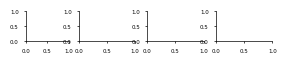

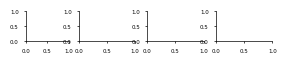

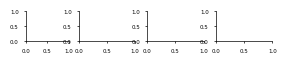

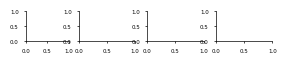

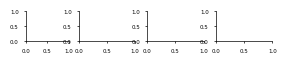

In [571]:
lo = fifi.FigureLayout('fig4_template.svg', autogenlayers=True, make_mplfigures=True, hide_layers=['Layer 1'])
lo.apply_mpl_methods() 
lo.clear_fflayer('mpl_layer') 

# Fig A

In [572]:
# set up figures
axs = np.empty(4, dtype=object)
axs[0] = lo.axes[('fig4A','1')]
axs[1] = lo.axes[('fig4A','2')]
axs[2] = lo.axes[('fig4A','3')]
axs[3] = lo.axes[('fig4A','4')]

In [573]:
# boxplot of loss
boxplot_orders = ['passthrough\n'+r'$I = 1$', '0th-order\ninterface', '1st-order\ninterface', '2nd-order\ninterface']
box_labels_base = ['passthrough']
box_labels = ['initial', 'final', 'baseline']
# boxcolors = ['lightgreen','darkgreen','grey']
boxcolors = ['thistle','rebeccapurple','grey']

# initial + final shifted left; baseline right — extra gap before third box
loss_box_x = [0.82, 1.72, 3.15]
ylim_loss = (0.18, 0.295)  # same for all panels; A1 was missing this (autoscale only)
x_sep_final_baseline = 0.5 * (loss_box_x[1] + loss_box_x[2])
lw_box = 0.5

for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        L = Y_base_norm
        data = [
            np.mean(L, axis=1)
        ]
        bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)
        ax.set_title(panel_title)
        c = 'black'
        patch = bplot['boxes'][0]
        patch.set_facecolor(to_rgba(c, alpha=0.5))
        patch.set_edgecolor(c)
        patch.set_linewidth(lw_box)
        bplot['whiskers'][0].set_color(c)
        bplot['whiskers'][1].set_color(c)
        bplot['whiskers'][0].set_linewidth(lw_box)
        bplot['whiskers'][1].set_linewidth(lw_box)
        bplot['caps'][0].set_color(c)
        bplot['caps'][1].set_color(c)
        bplot['caps'][0].set_linewidth(lw_box)
        bplot['caps'][1].set_linewidth(lw_box)
        for median in bplot['medians']:
            median.set_color('white')
            median.set_linewidth(lw_box)

    else:
        L = Y_norm[:, col - 1, :]

        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(
            data,
            positions=loss_box_x,
            tick_labels=box_labels,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
        )
        ax.set_title(panel_title)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        x_mid_initial_final = 0.5 * (loss_box_x[0] + loss_box_x[1])
        trans_xlabels = blended_transform_factory(ax.transData, ax.transAxes)
        for i, (patch, color) in enumerate(zip(bplot['boxes'], boxcolors)):
            patch.set_facecolor(to_rgba(color, alpha=0.5))
            patch.set_edgecolor(color)
            patch.set_linewidth(lw_box)
            bplot['whiskers'][2 * i].set_color(color)
            bplot['whiskers'][2 * i + 1].set_color(color)
            bplot['whiskers'][2 * i].set_linewidth(lw_box)
            bplot['whiskers'][2 * i + 1].set_linewidth(lw_box)
            bplot['caps'][2 * i].set_color(color)
            bplot['caps'][2 * i + 1].set_color(color)
            bplot['caps'][2 * i].set_linewidth(lw_box)
            bplot['caps'][2 * i + 1].set_linewidth(lw_box)
            bplot['medians'][i].set_color(color)
            bplot['medians'][i].set_linewidth(lw_box)
        # for median in bplot['medians']:
        #     median.set_color('black')
        bplot['medians'][2].set_color('grey')
        # bplot['medians'][2].set_linestyle('--')
        bplot['medians'][2].set_linewidth(lw_box)


        # pairwise paired t-tests with Bonferroni correction (m=3 comparisons)
        y_lo0, y_hi0 = ax.get_ylim()
        y_rng0 = y_hi0 - y_lo0
        comp_loss = [
            # ("initial vs final", data[0], data[1]),
            ("final vs baseline", data[1], data[2]),
            # ("initial vs baseline", data[0], data[2]),
        ]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        tops = [
            # plot_stats_lines(data[0], data[1], ax, bplot, loss_box_x, 0, 1, level=0, y0=0.23, h=0.005, p_value=p_bonf_loss[0]['p_corr']),
            plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, level=1, y0=0.2, h=-0.005, p_value=p_bonf_loss[0]['p_corr']),
            # plot_stats_lines(data[0], data[2], ax, bplot, loss_box_x, 0, 2, level=2, y0=0.29, h=0.005, p_value=p_bonf_loss[2]['p_corr']),
        ]
        ax.set_ylim(*ylim_loss)
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")

# vertical line between final and baseline
for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot(
        [x_sep_final_baseline, x_sep_final_baseline],
        ylim,
        color='black',
        linestyle='--',
        alpha=0.5,
        linewidth=0.5,
    )

axs[0].set_ylim(*ylim_loss)  # A1 had only autoscale; limits must match A2–A4 for identical y ticks
yticks_shared = [0.20,0.25, 0.3]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0.2,0.25, 0.3])
axs[0].set_ylabel('task error\n'+r'$||\widehat{y}||$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)

ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.000041, p_corr=0.000041, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.139446, p_corr=0.139446, significant=no
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.647967, p_corr=0.647967, significant=no


/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_40806/3212422964.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)


## ANOVA

In [574]:
# anova tests between passthrough and 3 baselines
datas = [
    np.mean(Y_base_norm, axis=1),
    np.mean(Y_norm[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(Y_norm[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(Y_norm[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)


Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=59.4764, p-value=0.0000
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = -6.480222199261137, Raw p-value = 0.0001, Bonferroni-corrected p-value = 0.0002
cond2 vs. cond0: stat = 7.131223710192027, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0001
cond3 vs. cond0: stat = 11.38026043936787, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000


In [575]:
# mean across subjects
print(np.mean(Y_base_norm))
print(np.mean(Y_norm[:, 0, :][:, [0,1,2,18,19,20]]))
print(np.mean(Y_norm[:, 1, :][:, [0,1,2,18,19,20]]))
print(np.mean(Y_norm[:, 2, :][:, [0,1,2,18,19,20]]))

0.2439573031495809
0.2822550619321366
0.2107642922076645
0.1973362203508972


In [576]:
# mean between baseline and final co-adaptive trials
print(np.median(Y_norm[:, 0, :][:, [0,1,2,18,19,20]]))
print(np.median(Y_norm[:, 0, :][:, 15:18]))
print('\n')
print(np.median(Y_norm[:, 1, :][:, [0,1,2,18,19,20]]))
print(np.median(Y_norm[:, 1, :][:, 15:18]))
print('\n')
print(np.median(Y_norm[:, 2, :][:, [0,1,2,18,19,20]]))
print(np.median(Y_norm[:, 2, :][:, 15:18]))



0.2728663921017102
0.2370604983185909


0.20955798535254822
0.20537108496675463


0.19672236883693767
0.19518506065743693


# Fig B

In [577]:
# set up figures
axs = np.empty(4, dtype=object)
axs[0] = lo.axes[('fig4B','1')]
axs[1] = lo.axes[('fig4B','2')]
axs[2] = lo.axes[('fig4B','3')]
axs[3] = lo.axes[('fig4B','4')]

In [578]:
# boxplot of loss
boxplot_orders = ['passthrough\n'+r'$I = 1$', '0th-order\ninterface', '1st-order\ninterface', '2nd-order\ninterface']
box_labels_base = ['passthrough']
box_labels = ['initial', 'final', 'baseline']
boxcolors = ['pink','red','grey']

# initial + final shifted left; baseline right — extra gap before third box
loss_box_x = [0.82, 1.72, 3.15]
x_sep_final_baseline = 0.5 * (loss_box_x[1] + loss_box_x[2])
lw_box = 0.5

for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        L = UH_base_norm
        data = [
            np.mean(L, axis=1)
        ]
        bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)
        # ax.set_title(panel_title)
        c = 'black'
        patch = bplot['boxes'][0]
        patch.set_facecolor(to_rgba(c, alpha=0.5))
        patch.set_edgecolor(c)
        patch.set_linewidth(lw_box)
        bplot['whiskers'][0].set_color(c)
        bplot['whiskers'][1].set_color(c)
        bplot['whiskers'][0].set_linewidth(lw_box)
        bplot['whiskers'][1].set_linewidth(lw_box)
        bplot['caps'][0].set_color(c)
        bplot['caps'][1].set_color(c)
        bplot['caps'][0].set_linewidth(lw_box)
        bplot['caps'][1].set_linewidth(lw_box)
        for median in bplot['medians']:
            median.set_color('white')
            median.set_linewidth(lw_box)

    else:
        L = UH_norm[:, col - 1, :]

        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(
            data,
            positions=loss_box_x,
            tick_labels=box_labels,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
        )
        # ax.set_title(panel_title)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        x_mid_initial_final = 0.5 * (loss_box_x[0] + loss_box_x[1])
        trans_xlabels = blended_transform_factory(ax.transData, ax.transAxes)

        for i, (patch, color) in enumerate(zip(bplot['boxes'], boxcolors)):
            patch.set_facecolor(to_rgba(color, alpha=0.5))
            patch.set_edgecolor(color)
            patch.set_linewidth(lw_box)
            bplot['whiskers'][2 * i].set_color(color)
            bplot['whiskers'][2 * i + 1].set_color(color)
            bplot['whiskers'][2 * i].set_linewidth(lw_box)
            bplot['whiskers'][2 * i + 1].set_linewidth(lw_box)
            bplot['caps'][2 * i].set_color(color)
            bplot['caps'][2 * i + 1].set_color(color)
            bplot['caps'][2 * i].set_linewidth(lw_box)
            bplot['caps'][2 * i + 1].set_linewidth(lw_box)
            bplot['medians'][i].set_color(color)
            bplot['medians'][i].set_linewidth(lw_box)
        # for median in bplot['medians']:
        #     median.set_color('black')
        bplot['medians'][2].set_color('grey')
        # bplot['medians'][2].set_linestyle('--')
        bplot['medians'][2].set_linewidth(lw_box)

        # pairwise paired t-tests with Bonferroni correction (m=3 comparisons)
        y_lo0, y_hi0 = ax.get_ylim()
        y_rng0 = y_hi0 - y_lo0
        comp_loss = [
            # ("initial vs final", data[0], data[1]),
            ("final vs baseline", data[1], data[2]),
            # ("initial vs baseline", data[0], data[2]),
        ]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        tops = [
            # plot_stats_lines(data[0], data[1], ax, bplot, loss_box_x, 0, 1, level=0, y0=0.15, h=0.01, p_value=p_bonf_loss[0]['p_corr']),
            plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, level=1, y0=0.175, h=0.01, p_value=p_bonf_loss[0]['p_corr']),
            # plot_stats_lines(data[0], data[2], ax, bplot, loss_box_x, 0, 2, level=2, y0=0.2, h=0.01, p_value=p_bonf_loss[2]['p_corr']),
        ]
        ax.set_ylim(y_lo0, max(y_hi0, max(tops) + 0.1 * y_rng0))
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")
    

# Same y-range on all panels (B1 autoscale vs B2–B4 stats-adjusted limits → align ticks)
y_lo_all = min(axs[k].get_ylim()[0] for k in range(4))
y_hi_all = max(axs[k].get_ylim()[1] for k in range(4))
for ax in axs:
    ax.set_ylim(y_lo_all, y_hi_all)

# vertical line between final and baseline
for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot(
        [x_sep_final_baseline, x_sep_final_baseline],
        ylim,
        color='black',
        linestyle='--',
        alpha=0.5,
        linewidth=0.5,
    )

yticks_shared = [0,0.1, 0.2]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0,0.1, 0.2])
axs[0].set_ylabel('human\neffort\n'+r'$||\widehat{u}_H||$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)


wilcoxon tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.001953, p_corr=0.001953, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.002284, p_corr=0.002284, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.003597, p_corr=0.003597, significant=yes


/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_40806/1937506592.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)


## ANOVA

In [579]:
# anova tests between passthrough and 3 baselines
datas = [
    np.mean(UH_base_norm, axis=1),
    np.mean(UH_norm[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(UH_norm[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(UH_norm[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)

Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=10.8033, p-value=0.0000
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = 7.153970529448427, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0001
cond2 vs. cond0: stat = 5.021878272898159, Raw p-value = 0.0005, Bonferroni-corrected p-value = 0.0016
cond3 vs. cond0: stat = 6.930293347205915, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0001


# Fig C

In [580]:
# set up figures
axs = np.empty(4, dtype=object)
axs[0] = lo.axes[('fig4C','1')]
axs[1] = lo.axes[('fig4C','2')]
axs[2] = lo.axes[('fig4C','3')]
axs[3] = lo.axes[('fig4C','4')]

In [581]:
# boxplot of loss
boxplot_orders = ['passthrough\n'+r'$I = 1$', '0th-order\ninterface', '1st-order\ninterface', '2nd-order\ninterface']
box_labels_base = ['passthrough']
box_labels = ['initial', 'final', 'baseline']
boxcolors = ['lightblue','blue','grey']

# initial + final shifted left; baseline right — extra gap before third box
loss_box_x = [0.82, 1.72, 3.15]
x_sep_final_baseline = 0.5 * (loss_box_x[1] + loss_box_x[2])
lw_box = 0.5

for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        L = UI_base_norm
        data = [
            np.mean(L, axis=1)
        ]
        bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)
        # ax.set_title(panel_title)
        c = 'black'
        patch = bplot['boxes'][0]
        patch.set_facecolor(to_rgba(c, alpha=0.5))
        patch.set_edgecolor(c)
        patch.set_linewidth(lw_box)
        bplot['whiskers'][0].set_color(c)
        bplot['whiskers'][1].set_color(c)
        bplot['whiskers'][0].set_linewidth(lw_box)
        bplot['whiskers'][1].set_linewidth(lw_box)
        bplot['caps'][0].set_color(c)
        bplot['caps'][1].set_color(c)
        bplot['caps'][0].set_linewidth(lw_box)
        bplot['caps'][1].set_linewidth(lw_box)
        for median in bplot['medians']:
            median.set_color('white')
            median.set_linewidth(lw_box)

    else:
        L = UI_norm[:, col - 1, :]

        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(
            data,
            positions=loss_box_x,
            tick_labels=box_labels,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
        )
        # ax.set_title(panel_title)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        x_mid_initial_final = 0.5 * (loss_box_x[0] + loss_box_x[1])
        trans_xlabels = blended_transform_factory(ax.transData, ax.transAxes)

        for i, (patch, color) in enumerate(zip(bplot['boxes'], boxcolors)):
            patch.set_facecolor(to_rgba(color, alpha=0.5))
            patch.set_edgecolor(color)
            patch.set_linewidth(lw_box)
            bplot['whiskers'][2 * i].set_color(color)
            bplot['whiskers'][2 * i + 1].set_color(color)
            bplot['whiskers'][2 * i].set_linewidth(lw_box)
            bplot['whiskers'][2 * i + 1].set_linewidth(lw_box)
            bplot['caps'][2 * i].set_color(color)
            bplot['caps'][2 * i + 1].set_color(color)
            bplot['caps'][2 * i].set_linewidth(lw_box)
            bplot['caps'][2 * i + 1].set_linewidth(lw_box)
            bplot['medians'][i].set_color(color)
            bplot['medians'][i].set_linewidth(lw_box)
        # for median in bplot['medians']:
        #     median.set_color('black')
        bplot['medians'][2].set_color('grey')
        # bplot['medians'][2].set_linestyle('--')
        bplot['medians'][2].set_linewidth(lw_box)

        # pairwise paired t-tests with Bonferroni correction (m=3 comparisons)
        y_lo0, y_hi0 = ax.get_ylim()
        y_rng0 = y_hi0 - y_lo0
        comp_loss = [
            # ("initial vs final", data[0], data[1]),
            ("final vs baseline", data[1], data[2]),
            # ("initial vs baseline", data[0], data[2]),
        ]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        tops = [
            # plot_stats_lines(data[0], data[1], ax, bplot, loss_box_x, 0, 1, level=0, y0=0.15, h=0.01, p_value=p_bonf_loss[0]['p_corr']),
            plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, level=1, y0=0.3, h=0.02, p_value=p_bonf_loss[0]['p_corr']),
            # plot_stats_lines(data[0], data[2], ax, bplot, loss_box_x, 0, 2, level=2, y0=0.2, h=0.01, p_value=p_bonf_loss[2]['p_corr']),
        ]
        ax.set_ylim(y_lo0, max(y_hi0, max(tops) + 0.1 * y_rng0))
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")
    

# Same y-range on all panels (B1 autoscale vs B2–B4 stats-adjusted limits → align ticks)
y_lo_all = min(axs[k].get_ylim()[0] for k in range(4))
y_hi_all = max(axs[k].get_ylim()[1] for k in range(4))
for ax in axs:
    ax.set_ylim(y_lo_all, y_hi_all)

# vertical line between final and baseline
for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot(
        [x_sep_final_baseline, x_sep_final_baseline],
        ylim,
        color='black',
        linestyle='--',
        alpha=0.5,
        linewidth=0.5,
    )

yticks_shared = [0.1, 0.2, 0.3]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0.1, 0.2, 0.3])
axs[0].set_ylabel('interface\neffort\n'+r'$||\widehat{u}_I||$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)


ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.000015, p_corr=0.000015, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.043872, p_corr=0.043872, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.047758, p_corr=0.047758, significant=yes


/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_40806/3780131713.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)


## ANOVA

In [582]:
# anova tests between passthrough and 3 baselines
datas = [
    np.mean(UI_base_norm, axis=1),
    np.mean(UI_norm[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(UI_norm[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(UI_norm[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)

Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=40.2608, p-value=0.0000
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = -12.464007624418716, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000
cond2 vs. cond0: stat = 6.890962599501146, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0001
cond3 vs. cond0: stat = 5.347235113720469, Raw p-value = 0.0003, Bonferroni-corrected p-value = 0.0010


# Fig D interface cost

In [583]:
# set up figures
axs = np.empty(4, dtype=object)
axs[0] = lo.axes[('fig4D','1')]
axs[1] = lo.axes[('fig4D','2')]
axs[2] = lo.axes[('fig4D','3')]
axs[3] = lo.axes[('fig4D','4')]

In [584]:
box_labels_base = ['passthrough']
box_labels = ['initial', 'final', 'baseline']
boxcolors = ['lightblue','blue','grey']
loss_box_x = [0.82, 1.72, 3.15]
ylim_interface = (1.2, 2.7)  # same for all panels; C1 was missing this (autoscale only)
x_sep_final_baseline = 0.5 * (loss_box_x[1] + loss_box_x[2])
lw_box = 0.5


for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        L = interface_loss_freqdomain_base
        data = [
            np.mean(L, axis=1)
        ]
        bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)
        # ax.set_title(panel_title)
        c = 'black'
        patch = bplot['boxes'][0]
        patch.set_facecolor(to_rgba(c, alpha=0.5))
        patch.set_edgecolor(c)
        patch.set_linewidth(lw_box)
        bplot['whiskers'][0].set_color(c)
        bplot['whiskers'][1].set_color(c)
        bplot['whiskers'][0].set_linewidth(lw_box)
        bplot['whiskers'][1].set_linewidth(lw_box)
        bplot['caps'][0].set_color(c)
        bplot['caps'][1].set_color(c)
        bplot['caps'][0].set_linewidth(lw_box)
        bplot['caps'][1].set_linewidth(lw_box)
        for median in bplot['medians']:
            median.set_color('white')
            median.set_linewidth(lw_box)

    else:
        L = interface_loss_freqdomain[:, col - 1, :]

        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(
            data,
            positions=loss_box_x,
            tick_labels=box_labels,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
        )
        # ax.set_title(panel_title)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        x_mid_initial_final = 0.5 * (loss_box_x[0] + loss_box_x[1])
        trans_xlabels = blended_transform_factory(ax.transData, ax.transAxes)
        for i, (patch, color) in enumerate(zip(bplot['boxes'], boxcolors)):
            patch.set_facecolor(to_rgba(color, alpha=0.5))
            patch.set_edgecolor(color)
            patch.set_linewidth(lw_box)
            bplot['whiskers'][2 * i].set_color(color)
            bplot['whiskers'][2 * i + 1].set_color(color)
            bplot['whiskers'][2 * i].set_linewidth(lw_box)
            bplot['whiskers'][2 * i + 1].set_linewidth(lw_box)
            bplot['caps'][2 * i].set_color(color)
            bplot['caps'][2 * i + 1].set_color(color)
            bplot['caps'][2 * i].set_linewidth(lw_box)
            bplot['caps'][2 * i + 1].set_linewidth(lw_box)
            bplot['medians'][i].set_color(color)
            bplot['medians'][i].set_linewidth(lw_box)
        # for median in bplot['medians']:
        #     median.set_color('black')
        bplot['medians'][2].set_color('grey')
        # bplot['medians'][2].set_linestyle('--')
        bplot['medians'][2].set_linewidth(lw_box)

        # pairwise paired t-tests with Bonferroni correction (m=3 comparisons)
        y_lo0, y_hi0 = ax.get_ylim()
        y_rng0 = y_hi0 - y_lo0
        y_lo, y_hi = ax.get_ylim()
        y_rng = y_hi - y_lo
        cap_top = max(
            float(bplot['caps'][2 * 1 + 1].get_ydata().max()),
            float(bplot['caps'][2 * 2 + 1].get_ydata().max()),
        )
        h = y_rng * 0.05
        y0 = cap_top + y_rng * (0.018)
        comp_loss = [
            # ("initial vs final", data[0], data[1]),
            ("final vs baseline", data[1], data[2]),
            # ("initial vs baseline", data[0], data[2]),
        ]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        tops = [
            # plot_stats_lines(data[0], data[1], ax, bplot, loss_box_x, 0, 1, level=0, y0=y0, h=h, p_value=p_bonf_loss[0]['p_corr']),
            plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, level=1, y0=y0, h=h, p_value=p_bonf_loss[0]['p_corr']),
            # plot_stats_lines(data[0], data[2], ax, bplot, loss_box_x, 0, 2, level=2, y0=y0, h=h, p_value=p_bonf_loss[2]['p_corr']),
        ]
        ax.set_ylim(*ylim_interface)
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")

# vertical line between final and baseline
for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot(
        [x_sep_final_baseline, x_sep_final_baseline],
        ylim,
        color='black',
        linestyle='--',
        alpha=0.5,
        linewidth=0.5,
    )

axs[0].set_ylim(*ylim_interface)  # match C2–C4 so y ticks align
yticks_shared = [1.5, 2.0, 2.5]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([1.5, 2.0, 2.5])
axs[0].set_ylabel('interface\ncost\n'+r'$c_I(H,I)$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)

ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.012932, p_corr=0.012932, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.048296, p_corr=0.048296, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.104440, p_corr=0.104440, significant=no


/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_40806/2802255060.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)


## ANOVA

In [585]:
# anova tests between passthrough and 3 baselines
datas = [
    np.mean(interface_loss_freqdomain_base, axis=1),
    np.mean(interface_loss_freqdomain[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(interface_loss_freqdomain[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(interface_loss_freqdomain[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)

Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=6.9412, p-value=0.0007
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = 0.09697855353972386, Raw p-value = 0.9247, Bonferroni-corrected p-value = 1.0000
cond2 vs. cond0: stat = 8.755548431308055, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000
cond3 vs. cond0: stat = 9.979816201359963, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000


# Fig E stability

In [586]:
# set up figures
axs = np.empty(4, dtype=object)
axs[0] = lo.axes[('fig4E','1')]
axs[1] = lo.axes[('fig4E','2')]
axs[2] = lo.axes[('fig4E','3')]
axs[3] = lo.axes[('fig4E','4')]

In [587]:
box_labels_base = ['passthrough']
box_labels = ['initial', 'final\n(co-adapt)', 'baseline\n(fixed)']
boxcolors = ['lightgreen','darkgreen','grey']
loss_box_x = [0.82, 1.72, 3.15]
ylim_interface = (0.1,1.1) # same for all panels; C1 was missing this (autoscale only)
x_sep_final_baseline = 0.5 * (loss_box_x[1] + loss_box_x[2])
lw_box = 0.5


for col, panel_title in enumerate(boxplot_orders):
    ax = axs[col]
    if col == 0:
        L = L_min_distance_base
        data = [
            np.mean(L, axis=1)
        ]
        bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)
        # ax.set_title(panel_title)
        c = 'black'
        patch = bplot['boxes'][0]
        patch.set_facecolor(to_rgba(c, alpha=0.5))
        patch.set_edgecolor(c)
        patch.set_linewidth(lw_box)
        bplot['whiskers'][0].set_color(c)
        bplot['whiskers'][1].set_color(c)
        bplot['whiskers'][0].set_linewidth(lw_box)
        bplot['whiskers'][1].set_linewidth(lw_box)
        bplot['caps'][0].set_color(c)
        bplot['caps'][1].set_color(c)
        bplot['caps'][0].set_linewidth(lw_box)
        bplot['caps'][1].set_linewidth(lw_box)
        for median in bplot['medians']:
            median.set_color('white')
            median.set_linewidth(lw_box)

    else:
        L = L_min_distance[:, col - 1, :]

        data = [
            np.mean(L[:, 3:6], axis=1),
            np.mean(L[:, 15:18], axis=1),
            np.mean(L[:, [0,1,2,18,19,20]], axis=1),
        ]
        bplot = ax.boxplot(
            data,
            positions=loss_box_x,
            tick_labels=box_labels,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
        )
        # ax.set_title(panel_title)
        ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
        x_mid_initial_final = 0.5 * (loss_box_x[0] + loss_box_x[1])
        trans_xlabels = blended_transform_factory(ax.transData, ax.transAxes)
        for i, (patch, color) in enumerate(zip(bplot['boxes'], boxcolors)):
            patch.set_facecolor(to_rgba(color, alpha=0.5))
            patch.set_edgecolor(color)
            patch.set_linewidth(lw_box)
            bplot['whiskers'][2 * i].set_color(color)
            bplot['whiskers'][2 * i + 1].set_color(color)
            bplot['whiskers'][2 * i].set_linewidth(lw_box)
            bplot['whiskers'][2 * i + 1].set_linewidth(lw_box)
            bplot['caps'][2 * i].set_color(color)
            bplot['caps'][2 * i + 1].set_color(color)
            bplot['caps'][2 * i].set_linewidth(lw_box)
            bplot['caps'][2 * i + 1].set_linewidth(lw_box)
            bplot['medians'][i].set_color(color)
            bplot['medians'][i].set_linewidth(lw_box)
        # for median in bplot['medians']:
        #     median.set_color('black')
        bplot['medians'][2].set_color('grey')
        # bplot['medians'][2].set_linestyle('--')
        bplot['medians'][2].set_linewidth(lw_box)

        # pairwise paired t-tests with Bonferroni correction (m=3 comparisons)
        y_lo0, y_hi0 = ax.get_ylim()
        y_rng0 = y_hi0 - y_lo0
        y_lo, y_hi = ax.get_ylim()
        y_rng = y_hi - y_lo
        cap_top = max(
            float(bplot['caps'][2 * 1 + 1].get_ydata().max()),
            float(bplot['caps'][2 * 2 + 1].get_ydata().max()),
        )
        h = y_rng * 0.05
        y0 = cap_top + y_rng * (0.018)
        comp_loss = [
            # ("initial vs final", data[0], data[1]),
            ("final vs baseline", data[1], data[2]),
            # ("initial vs baseline", data[0], data[2]),
        ]
        p_bonf_loss = pairwise_paired_ttests_bonferroni(comp_loss, label=f"{panel_title}: ")
        tops = [
            # plot_stats_lines(data[0], data[1], ax, bplot, loss_box_x, 0, 1, level=0, y0=y0, h=h, p_value=p_bonf_loss[0]['p_corr']),
            plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, level=1, y0=y0, h=h, p_value=p_bonf_loss[0]['p_corr']),
            # plot_stats_lines(data[0], data[2], ax, bplot, loss_box_x, 0, 2, level=2, y0=y0, h=h, p_value=p_bonf_loss[2]['p_corr']),
        ]
        ax.set_ylim(*ylim_interface)
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(direction="in")

# vertical line between final and baseline
for j in [1, 2, 3]:
    ylim = axs[j].get_ylim()
    axs[j].plot(
        [x_sep_final_baseline, x_sep_final_baseline],
        ylim,
        color='black',
        linestyle='--',
        alpha=0.5,
        linewidth=0.5,
    )

axs[0].set_ylim(*ylim_interface)  # match C2–C4 so y ticks align
yticks_shared = [0,0.5, 1.0]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0,0.5, 1.0])
axs[0].set_ylabel('stability\nmargin')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)

/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_40806/2638902429.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)


wilcoxon tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.001953, p_corr=0.001953, significant=yes
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.294211, p_corr=0.294211, significant=no
ttest_rel tests + bonferroni (m=1, alpha=0.05):
  final vs baseline: p_raw=0.029523, p_corr=0.029523, significant=yes


## ANOVA

In [588]:
# anova tests between passthrough and 3 baselines
datas = [
    np.mean(L_min_distance_base, axis=1),
    np.mean(L_min_distance[:, 0, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(L_min_distance[:, 1, :][:, [0,1,2,18,19,20]], axis=1),
    np.mean(L_min_distance[:, 2, :][:, [0,1,2,18,19,20]], axis=1),
]
stats_test_multiple_groups(datas)


Residuals appear to be normally distributed (fail to reject H0).
One-way ANOVA Statistic=21.5220, p-value=0.0000
ANOVA Test: significant difference. Do paired t-tests
cond1 vs. cond0: stat = 9.378884316394203, Raw p-value = 0.0000, Bonferroni-corrected p-value = 0.0000
cond2 vs. cond0: stat = -0.5830529770730747, Raw p-value = 0.5728, Bonferroni-corrected p-value = 1.0000
cond3 vs. cond0: stat = -2.492706770300644, Raw p-value = 0.0318, Bonferroni-corrected p-value = 0.0955


# write to figure layout

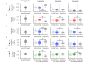

In [589]:
lo.append_figure_to_layer(lo.figures['fig4A'], 'A1', cleartarget=True)
lo.append_figure_to_layer(lo.figures['fig4B'], 'B1', cleartarget=True)
lo.append_figure_to_layer(lo.figures['fig4C'], 'C1', cleartarget=True)
lo.append_figure_to_layer(lo.figures['fig4D'], 'D1', cleartarget=True)
lo.append_figure_to_layer(lo.figures['fig4E'], 'E1', cleartarget=True)

lo.write_svg('fig4_template.svg')
display(SVG('fig4_template.svg'))